In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
kagglehub.dataset_download('somesh24/spambase')

/kaggle/input/datasets/somesh24/spambase/spambase_csv.csv


'/kaggle/input/datasets/somesh24/spambase'

# Cell 1 – Import Libraries

In [2]:
import os
import re
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'savefig.dpi': 600,
})

sns.set(style="whitegrid")

def set_plot_style():
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 12,
        'axes.labelweight': 'bold',
        'axes.titleweight': 'bold',
        'axes.labelsize': 13,
        'axes.titlesize': 14,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'savefig.dpi': 600,
    })

def save_current_plot(name, folder="figures", close=False):
    os.makedirs(folder, exist_ok=True)
    safe_name = re.sub(r'[^A-Za-z0-9_\-]+', '_', str(name)).strip('_')
    fig = plt.gcf()
    path = os.path.join(folder, f"{safe_name}.eps")
    fig.savefig(path, format="eps", dpi=600, bbox_inches="tight")
    print(f"Saved: {path}")
    if close:
        plt.close(fig)
    return path

# Cell 2 – Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/somesh24/spambase/spambase_csv.csv")

df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


# Cell 3 – Check Dataset

In [4]:
print(df.shape)

print(df.info())

df.describe()

(4601, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report      

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


# Cell 4 – Handle Missing Values

In [5]:
print(df.isnull().sum())

imputer = SimpleImputer(strategy="mean")

X = df.iloc[:, :-1]

df.iloc[:, :-1] = imputer.fit_transform(X)

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

# Cell 5 – Class Distribution

Saved: figures/class_distribution.eps


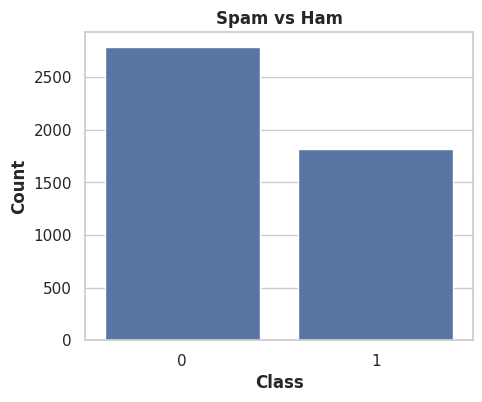

In [6]:
plt.figure(figsize=(5,4))

sns.countplot(x=df.iloc[:,-1])

plt.title("Spam vs Ham")
plt.xlabel("Class")
plt.ylabel("Count")

save_current_plot("class_distribution")

plt.show()

# Cell 6 – Correlation Heatmap

Saved: figures/correlation_heatmap.eps


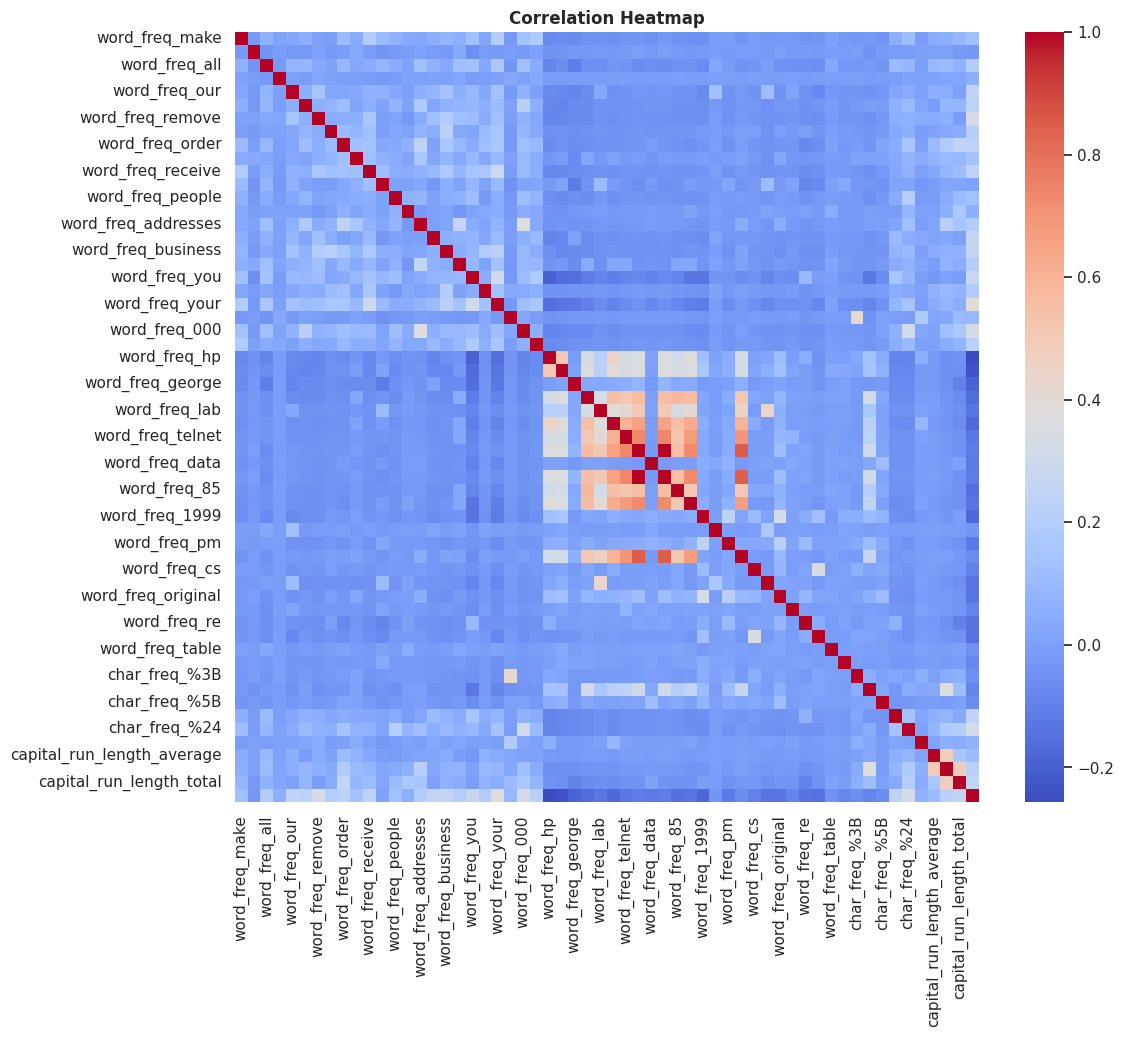

In [7]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

save_current_plot("correlation_heatmap")

plt.show()

# Cell 7 – Train-Test Split

In [8]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Cell 8 – Standardize Features

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Cell 9 – Baseline Logistic Regression

In [10]:
start = time.time()

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

end = time.time()

lr_time = end - start

# Cell 10 – Logistic Regression Evaluation

In [11]:
y_pred = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.9196525515743756
Precision: 0.9316939890710383
Recall : 0.8743589743589744
F1 Score : 0.9021164021164021
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       531
           1       0.93      0.87      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



# Cell 11 – Logistic Regression Confusion Matrix

Saved: figures/logistic_confusion_matrix.eps


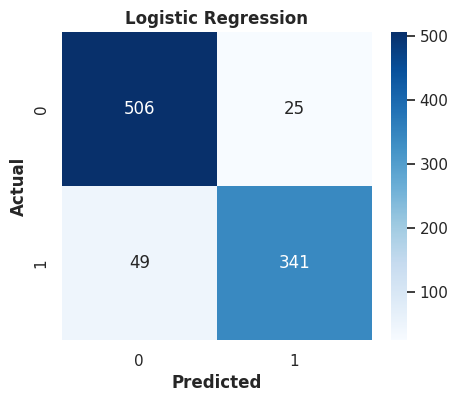

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

save_current_plot("logistic_confusion_matrix")

plt.show()

# Cell 12 – Logistic Regression Hyperparameter Tuning

In [13]:
params = {
    'penalty':['l1','l2'],
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear','saga']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5
)

grid_lr.fit(X_train,y_train)

print(grid_lr.best_params_)
print(grid_lr.best_score_)

best_lr = grid_lr.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
0.9274456521739131


# Cell 13 – Linear SVM

In [15]:
start = time.time()

svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train,y_train)

end = time.time()

linear_time = end-start

# Cell 14 – SVM Kernels Comparison

Saved: figures/linear_kernel_confusion_matrix.eps


<Figure size 600x500 with 0 Axes>

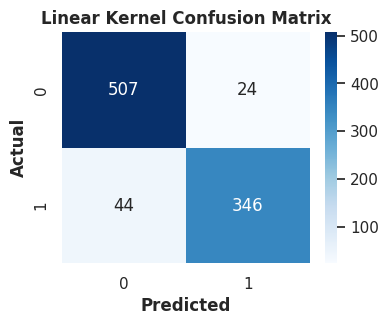


LINEAR Kernel Confusion Matrix
[[507  24]
 [ 44 346]]
Saved: figures/poly_kernel_confusion_matrix.eps


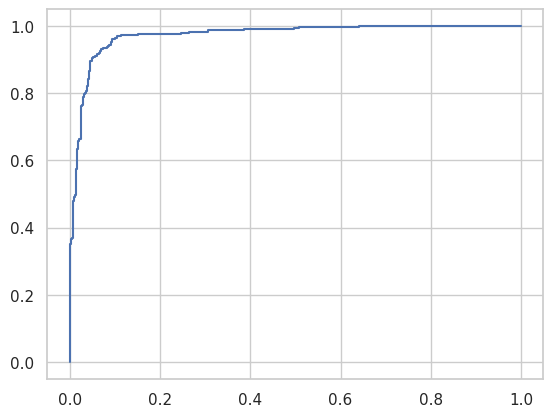

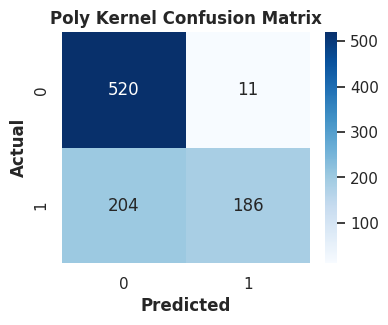


POLY Kernel Confusion Matrix
[[520  11]
 [204 186]]
Saved: figures/rbf_kernel_confusion_matrix.eps


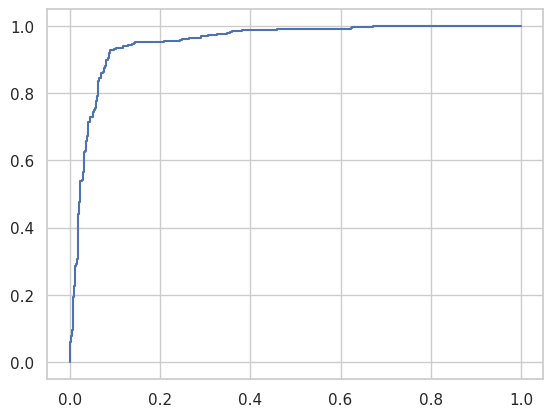

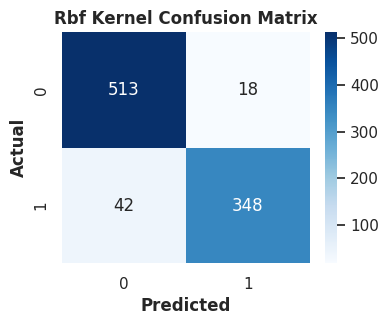


RBF Kernel Confusion Matrix
[[513  18]
 [ 42 348]]
Saved: figures/sigmoid_kernel_confusion_matrix.eps


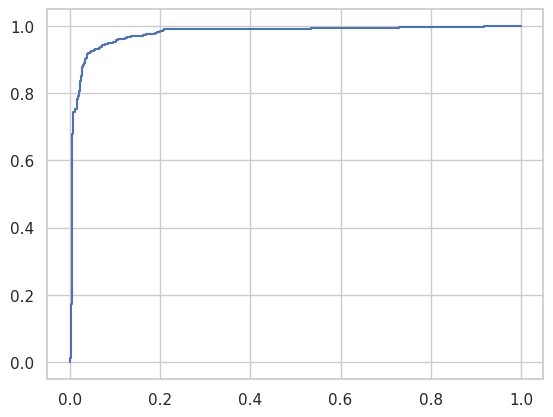

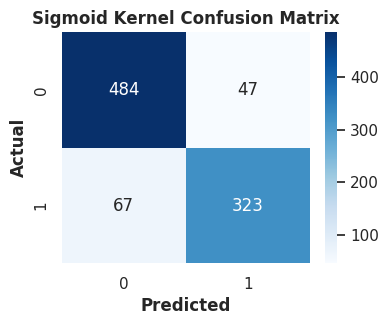


SIGMOID Kernel Confusion Matrix
[[484  47]
 [ 67 323]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/svm_kernel_roc_curves.eps


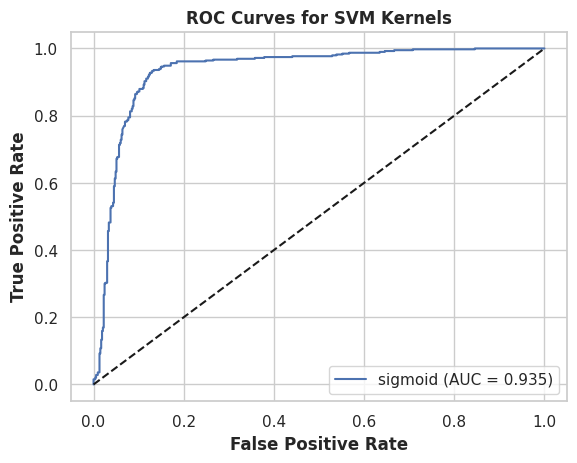

,Kernel,Accuracy,F1 Score,Training Time
0,linear,0.926167,0.910526,2.554567
1,poly,0.766558,0.633731,2.719600
2,rbf,0.934853,0.920635,1.679404
3,sigmoid,0.876221,0.850000,1.729649


In [16]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

results = []

plt.figure(figsize=(6,5))

for k in kernels:

    model = SVC(kernel=k, probability=True)

    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()

    pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    # Confusion Matrix
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(4,3))

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')
    
    plt.title(f"{k.capitalize()} Kernel Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    save_current_plot(f"{k}_kernel_confusion_matrix")

    plt.show()

    print(f"\n{k.upper()} Kernel Confusion Matrix")
    print(cm)

    # ROC Curve
    prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{k} (AUC = {roc_auc:.3f})")

    results.append([
        k,
        acc,
        f1,
        end - start
    ])

# ROC Plot
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for SVM Kernels")
plt.legend()

save_current_plot("svm_kernel_roc_curves")

plt.show()

# Performance Table
svm_results = pd.DataFrame(
    results,
    columns=["Kernel", "Accuracy", "F1 Score", "Training Time"]
)

svm_results

# Cell 15 – SVM Performance Visualization

Saved: figures/svm_kernel_accuracy.eps


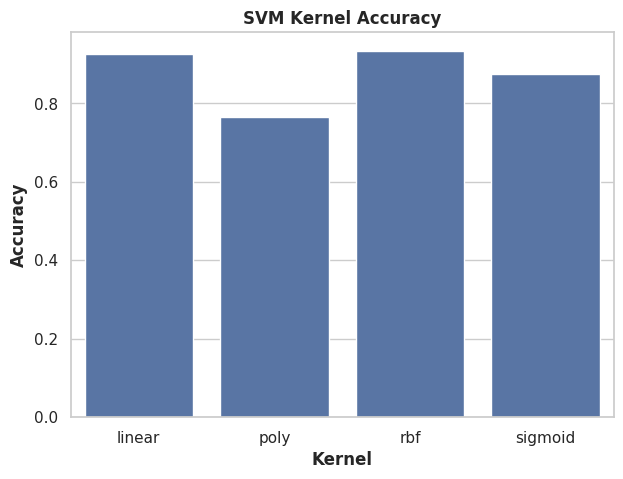

In [17]:
plt.figure(figsize=(7,5))

sns.barplot(data=svm_results,
            x="Kernel",
            y="Accuracy")

plt.title("SVM Kernel Accuracy")

save_current_plot("svm_kernel_accuracy")

plt.show()

# Cell 16 – SVM Hyperparameter Tuning

In [18]:
param_grid={
    'kernel':['linear','poly','rbf','sigmoid'],
    'C':[0.1,1,10,100],
    'gamma':['scale','auto']
}

grid_svm=GridSearchCV(
    SVC(),
    param_grid,
    cv=5
)

grid_svm.fit(X_train,y_train)

print(grid_svm.best_params_)
print(grid_svm.best_score_)

best_svm = grid_svm.best_estimator_

{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
0.9307065217391305


In [19]:
tuning_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "SVM"
    ],

    "Search Method":[
        "Grid Search",
        "Grid Search"
    ],

    "Best Parameters":[
        grid_lr.best_params_,
        grid_svm.best_params_
    ],

    "Best CV Accuracy":[
        grid_lr.best_score_,
        grid_svm.best_score_
    ]

})

tuning_results

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}",0.927446
1,SVM,Grid Search,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.930707


# Cell 17 – 5-Fold Cross Validation

In [20]:
lr_scores = cross_val_score(
    best_lr,
    X_train,
    y_train,
    cv=5
)

svm_scores = cross_val_score(
    best_svm,
    X_train,
    y_train,
    cv=5
)

print("Logistic Regression")

print(lr_scores)

print("Average:",lr_scores.mean())

print()

print("SVM")

print(svm_scores)

print("Average:",svm_scores.mean())

Logistic Regression
[0.9375     0.9048913  0.93342391 0.93070652 0.93070652]
Average: 0.9274456521739131

SVM
[0.93478261 0.9048913  0.94021739 0.9375     0.9361413 ]
Average: 0.9307065217391305


# Cell 18 – Cross Validation Plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


      Fold  Logistic Regression       SVM
0        1             0.937500  0.934783
1        2             0.904891  0.904891
2        3             0.933424  0.940217
3        4             0.930707  0.937500
4        5             0.930707  0.936141
5  Average             0.927446  0.930707
Saved: figures/cross_validation.eps


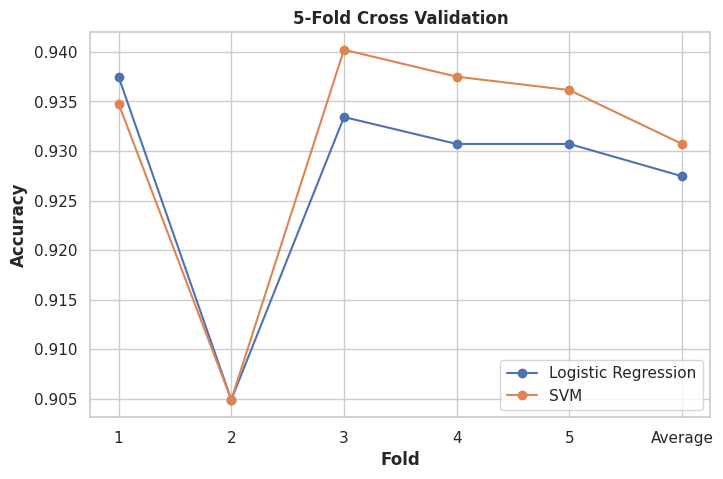

In [22]:
cv_df = pd.DataFrame({

    "Fold":[1,2,3,4,5],

    "Logistic Regression":lr_scores,

    "SVM":svm_scores

})

average_row = pd.DataFrame({

    "Fold":["Average"],

    "Logistic Regression":[lr_scores.mean()],

    "SVM":[svm_scores.mean()]

})

cv_df = pd.concat([cv_df, average_row], ignore_index=True)

print(cv_df)

plt.figure(figsize=(8,5))

x = ["1","2","3","4","5","Average"]

plt.plot(x, cv_df["Logistic Regression"],
         marker='o', label='Logistic Regression')

plt.plot(x, cv_df["SVM"],
         marker='o', label='SVM')

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation")
plt.legend()

save_current_plot("cross_validation")

plt.show()

# Cell 19 – Final Comparison Table

In [23]:
comparison = pd.DataFrame({

    "Model":["Logistic Regression","SVM"],

    "Accuracy":[
        accuracy_score(y_test,best_lr.predict(X_test)),
        accuracy_score(y_test,best_svm.predict(X_test))
    ],

    "Training Time":[
        lr_time,
        linear_time
    ]
})

comparison

,Model,Accuracy,Training Time
0,Logistic Regression,0.916395,0.030075
1,SVM,0.934853,0.628067


In [24]:
!zip -r output.zip /kaggle/working/figures

updating: kaggle/working/figures/ (stored 0%)
updating: kaggle/working/figures/logistic_confusion_matrix.eps (deflated 98%)
updating: kaggle/working/figures/cross_validation.eps (deflated 67%)
updating: kaggle/working/figures/correlation_heatmap.eps (deflated 99%)
updating: kaggle/working/figures/class_distribution.eps (deflated 64%)
updating: kaggle/working/figures/svm_kernel_accuracy.eps (deflated 64%)
  adding: kaggle/working/figures/poly_kernel_confusion_matrix.eps (deflated 98%)
  adding: kaggle/working/figures/linear_kernel_confusion_matrix.eps (deflated 98%)
  adding: kaggle/working/figures/rbf_kernel_confusion_matrix.eps (deflated 98%)
  adding: kaggle/working/figures/sigmoid_kernel_confusion_matrix.eps (deflated 97%)
  adding: kaggle/working/figures/svm_kernel_roc_curves.eps (deflated 65%)
